In [7]:
import sys

!{sys.executable} -m pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB 320.0 kB/s eta 0:00:26
   - -------------------------------------- 0.2/8.1 MB 2.5 MB/s eta 0:00:04
   --- ------------------------------------ 0.7/8.1 MB 5.5 MB/s eta 0:00:02
   ------ --------------------------------- 1.2/8.1 MB 7.0 MB/s eta 0:00:01
   --------- ------------------------------ 1.9/8.1 MB 8.5 MB/s eta 0:00:01
   ------------- -------------------------- 2.7/8.1 MB 10.0 MB/s eta 0:00:01
   ----------------- ---------------------- 3.5/8.1 MB 11.2 MB/s eta 0:00:01
   --------------------- ------------------ 4.4/8.1 MB 12.1 MB/s eta 0:00:01
   -------------------------- ------------- 5.4/8.1 MB 13.7 MB/s eta 0:00:01
   --------------------------------- ------ 6.7/8.1 MB 14.8 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.1 MB 16.1 MB/s eta 0:00:01
   ---------------


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys

!{sys.executable} -m pip install mysql-connector-python

   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB 660.6 kB/s eta 0:00:27
    --------------------------------------- 0.3/17.7 MB 3.8 MB/s eta 0:00:05
   - -------------------------------------- 0.7/17.7 MB 5.2 MB/s eta 0:00:04
   -- ------------------------------------- 1.0/17.7 MB 5.8 MB/s eta 0:00:03
   -- ------------------------------------- 1.1/17.7 MB 5.1 MB/s eta 0:00:04
   --- ------------------------------------ 1.3/17.7 MB 5.0 MB/s eta 0:00:04
   ---- ----------------------------------- 1.8/17.7 MB 5.8 MB/s eta 0:00:03
   ----- ---------------------------------- 2.5/17.7 MB 7.0 MB/s eta 0:00:03
   ------- -------------------------------- 3.2/17.7 MB 8.2 MB/s eta 0:00:02
   --------- ------------------------------ 4.2/17.7 MB 9.2 MB/s eta 0:00:02
   ----------- ---------------------------- 5.3/17.7 MB 10.5 MB/s eta 0:00:02
   -------------- ------------------------- 6.4/17.7 MB 12.1 MB/s eta 0:00:01
  


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\juane\AppData\Local\Temp\ipykernel_7280\2758988961.py:42: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


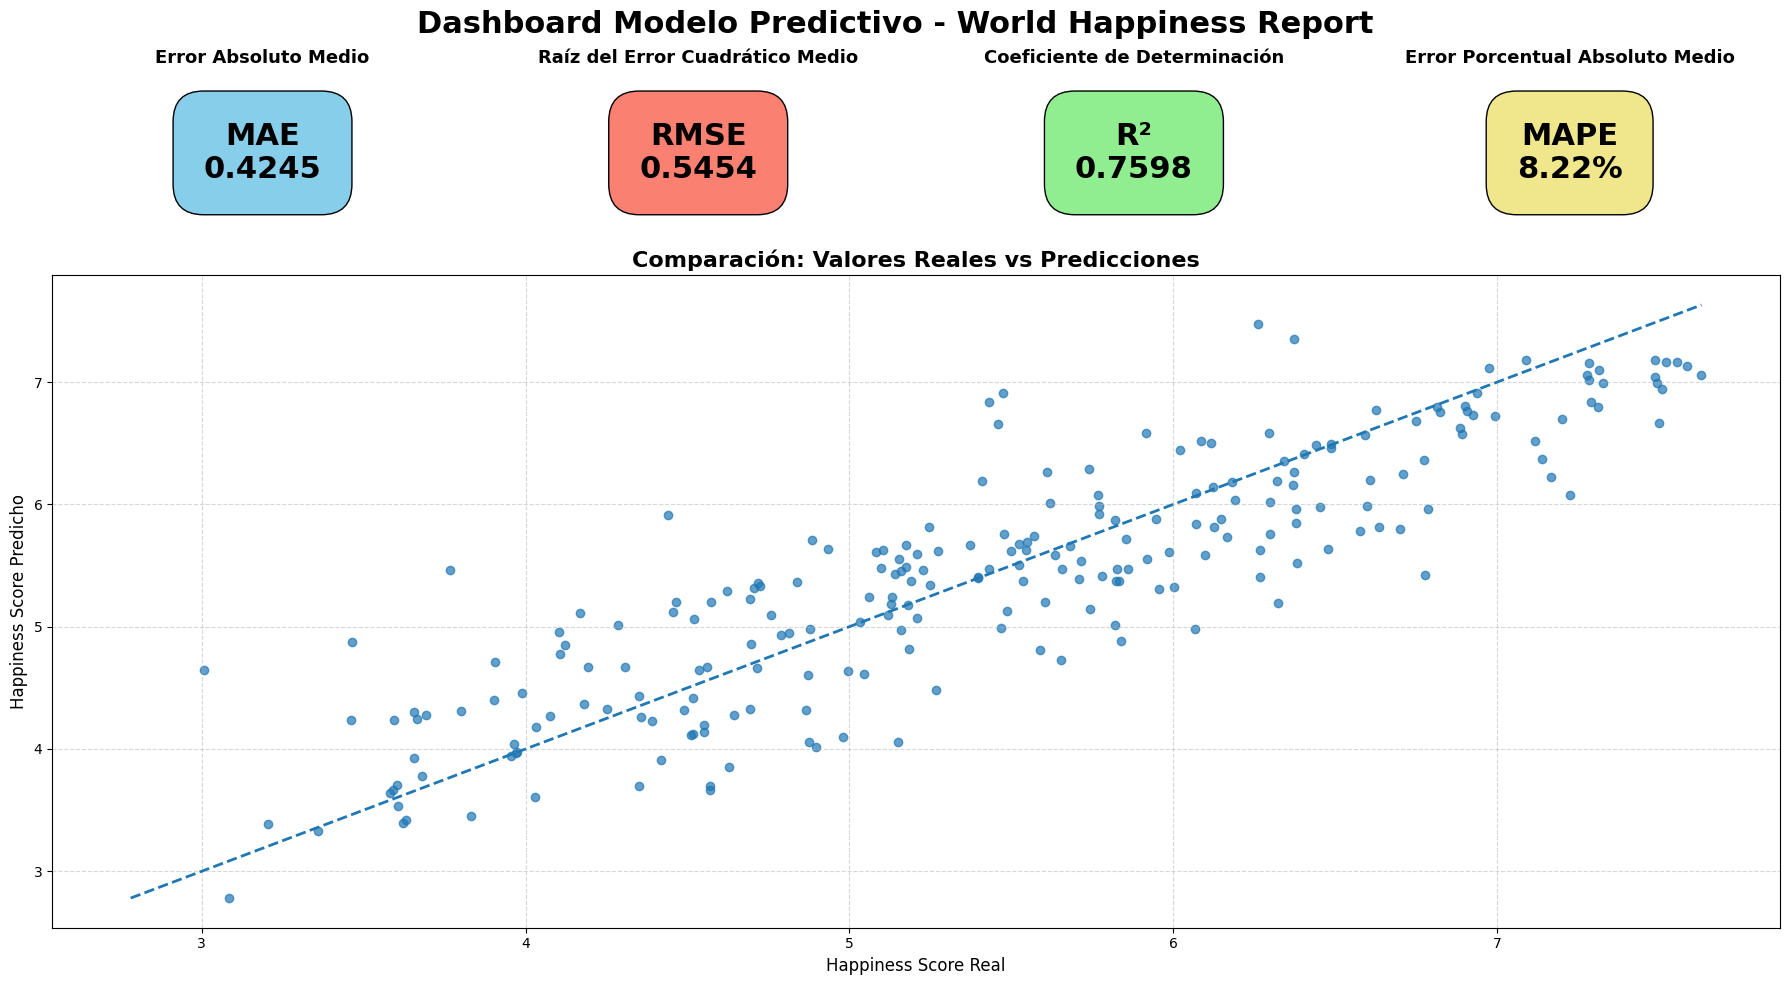

In [ ]:
# Importar librerias 

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
    mean_absolute_percentage_error
)

import mysql.connector


# Conexion a la base de datos 

conexion = mysql.connector.connect(
    host="localhost",
    port=3308,
    user="predictions_user",
    password="predictions_password",
    database="predictions_db"
)


# Consulta

query = """
SELECT
    happiness_score,
    predicted_score
FROM predictions
"""

df = pd.read_sql(query, conexion)

conexion.close()


# Variables 

y_real = df["happiness_score"]
y_pred = df["predicted_score"]


# Sacar metricas

mae = mean_absolute_error(y_real, y_pred)

rmse = root_mean_squared_error(y_real, y_pred)

r2 = r2_score(y_real, y_pred)

mape = mean_absolute_percentage_error(y_real, y_pred) * 100


# Dashboard

fig = plt.figure(figsize=(18, 10))

# Grid general
gs = fig.add_gridspec(
    2, 4,
    height_ratios=[1, 4]
)


# MAE
ax_mae = fig.add_subplot(gs[0, 0])

ax_mae.axis("off")

ax_mae.text(
    0.5,
    0.5,
    f"MAE\n{mae:.4f}",
    fontsize=22,
    fontweight="bold",
    ha="center",
    va="center",
    bbox=dict(
        facecolor="skyblue",
        edgecolor="black",
        boxstyle="round,pad=1"
    )
)

ax_mae.set_title(
    "Error Absoluto Medio",
    fontsize=13,
    fontweight="bold"
)


# RMSE
ax_rmse = fig.add_subplot(gs[0, 1])

ax_rmse.axis("off")

ax_rmse.text(
    0.5,
    0.5,
    f"RMSE\n{rmse:.4f}",
    fontsize=22,
    fontweight="bold",
    ha="center",
    va="center",
    bbox=dict(
        facecolor="salmon",
        edgecolor="black",
        boxstyle="round,pad=1"
    )
)

ax_rmse.set_title(
    "Raíz del Error Cuadrático Medio",
    fontsize=13,
    fontweight="bold"
)


# R^2
ax_r2 = fig.add_subplot(gs[0, 2])

ax_r2.axis("off")

ax_r2.text(
    0.5,
    0.5,
    f"R²\n{r2:.4f}",
    fontsize=22,
    fontweight="bold",
    ha="center",
    va="center",
    bbox=dict(
        facecolor="lightgreen",
        edgecolor="black",
        boxstyle="round,pad=1"
    )
)

ax_r2.set_title(
    "Coeficiente de Determinación",
    fontsize=13,
    fontweight="bold"
)


# MAPE
ax_mape = fig.add_subplot(gs[0, 3])

ax_mape.axis("off")

ax_mape.text(
    0.5,
    0.5,
    f"MAPE\n{mape:.2f}%",
    fontsize=22,
    fontweight="bold",
    ha="center",
    va="center",
    bbox=dict(
        facecolor="khaki",
        edgecolor="black",
        boxstyle="round,pad=1"
    )
)

ax_mape.set_title(
    "Error Porcentual Absoluto Medio",
    fontsize=13,
    fontweight="bold"
)


# Grafica valores reales vs predicciones 

ax_scatter = fig.add_subplot(gs[1, :])

ax_scatter.scatter(
    y_real,
    y_pred,
    alpha=0.7
)

min_val = min(y_real.min(), y_pred.min())
max_val = max(y_real.max(), y_pred.max())

ax_scatter.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2
)

ax_scatter.set_title(
    "Comparación: Valores Reales vs Predicciones",
    fontsize=16,
    fontweight="bold"
)

ax_scatter.set_xlabel(
    "Happiness Score Real",
    fontsize=12
)

ax_scatter.set_ylabel(
    "Happiness Score Predicho",
    fontsize=12
)

ax_scatter.grid(
    True,
    linestyle="--",
    alpha=0.5
)

#Titulo
plt.suptitle(
    "Dashboard Modelo Predictivo - World Happiness Report",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.show()